In [164]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)

<module 'MyHaloPS' from '/cosma/home/dp004/dc-zhan5/MyHaloPS.py'>

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [159]:
pos = halos["GroupPos"]/1e3

In [6]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [7]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [8]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [9]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [10]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [11]:
sum_sfrs = np.zeros(len(halos["GroupFirstSub"]))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


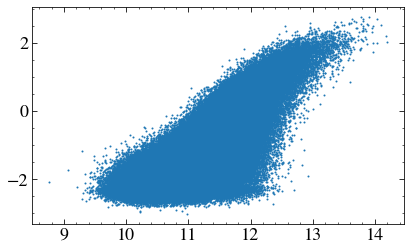

In [162]:
plt.scatter(mvir, sum_sfrs, s=1)

In [169]:
mvir[0]

14.033934

In [168]:
ps.compute_shotnoise(10**sum_sfrs[mvir>13], boxsize=205)

18739.62505679066

In [12]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [13]:

sum_sat_mass = np.zeros(len(halos["GroupFirstSub"]))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [14]:
mvir = np.log10(halos["Group_M_TopHat200"])+10

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [15]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [30]:
mvir

array([14.033934, 14.198841, 14.179142, ...,      -inf,  8.942679,
        8.378408], dtype=float32)

In [171]:
odir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all/mvir/ihalo"
with open(f"{odir}/sat_sfr_sum_logM10.txt", "w") as f:
    print("# ihalo, Mvir, x, y, z, logSFR", file=f)
    for ihalo in range(len(halos["GroupFirstSub"])):
        if mvir[ihalo] >= 10:
            print(ihalo, mvir[ihalo], pos[:,0][ihalo],pos[:,1][ihalo],pos[:,2][ihalo],sum_sfrs[ihalo],  file=f)

Text(0, 0.5, 'log(Sum sat sub mass)')

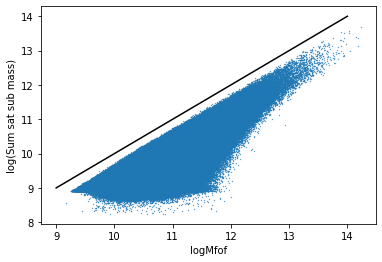

In [23]:
plt.scatter(np.log10(halos["GroupMass"])+10, sum_sat_mass, s=0.1)
plt.plot([9,14], [9,14], c="k")
plt.xlabel("logMfof")
plt.ylabel("log(Sum sat sub mass)")


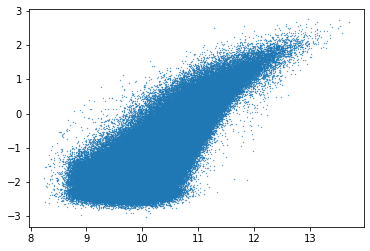

In [22]:
plt.scatter(sum_sat_mass, sum_sfrs, s=0.1)

In [33]:
print(mvir[1875188])

10.0


In [1]:
logM =11
dlogM = 0.5
mask2 = (mvir > logM) & (mvir < logM+dlogM) 

NameError: name 'mvir' is not defined

In [16]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [17]:
import matplotlib.ticker as ticker




In [18]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

[10.07733468 11.24614748 11.45967398 11.72655392 12.67361096]


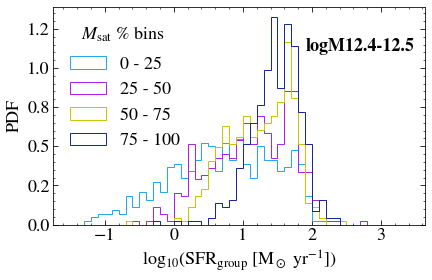

In [157]:
bins=np.arange(-1.5, 3.5, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["#23AAEB","#AC23EB","#c8c800","#18289F"]
logM = 12.4
mask2 = (mvir> logM) & (mvir < logM+0.1) 
median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.97,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$M_{\rm sat}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#plt.savefig("../figures/hist_logM12.4-12.5_msat.pdf", format="pdf", bbox_inches="tight")

[10.07733468 11.24614748 11.45967398 11.72655392 12.67361096]


Text(0.3, 0.85, 'Split by $\\rm M_{sat}$')

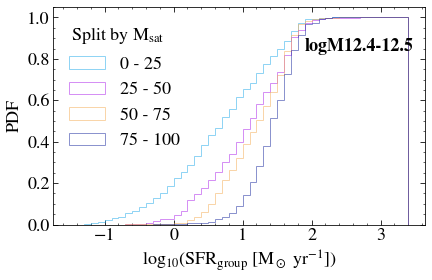

In [25]:
bins=np.arange(-1.5, 3.5, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
logM = 12.4
mask2 = (mvir> logM) & (mvir < logM+0.1) 
median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True,cumulative=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.97,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by $\rm M_{sat}$", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.savefig("../figures/hist_logM12.4-12.5_msat.pdf", format="pdf", bbox_inches="tight")

[ 9.85403245 10.94482788 11.17667806 11.4722977  12.58831736]


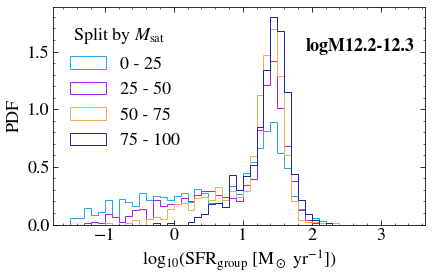

In [67]:
bins=np.arange(-1.5, 3.5, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]

logM = 12.2
mask2 = (mvir> logM) & (mvir < logM+0.1) 
median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.97,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by $M_{\rm sat}$", (0.3,0.85), xycoords="axes fraction", ha="right")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#plt.savefig("../figures/hist_logM12.4-12.5_msat.pdf", format="pdf", bbox_inches="tight")

In [85]:
logMs = np.arange(11,14, 0.1)

In [96]:

nbins = len(logMs)

compute_iqr = True

new_medians_arr = np.zeros((4,nbins), dtype=float)

if compute_iqr:
    new_iqrs_arr = np.zeros((4,nbins), dtype=float)
    orig_iqrs = []

for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    
    percentile_list = [0, 25, 50, 75, 100]
    percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)
    
    if compute_iqr:
        if np.sum(mask2) > 4:
            ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
            iqr = ps[1] - ps[0]
            orig_iqrs.append(iqr)


    
    

    for ip, percentile in enumerate(percentiles[:4]):
        mask = (sum_sat_mass[mask2] > percentiles[ip]) & (sum_sat_mass[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
        masks.append(mask)
        #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
        if compute_iqr:
            if len(group_sfrs[mask2][mask]) > 4:
                ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
                iqr = ps[1] - ps[0]
                new_iqrs_arr[ip][ibin] = iqr
            else:
                new_iqrs_arr[ip][ibin] = np.nan
        
        #print(np.nanstd(group_sfrs[mask2][mask]))
        med = np.nanmedian(group_sfrs[mask2][mask])
        new_medians.append(med)
        new_medians_arr[ip][ibin] = med
        

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


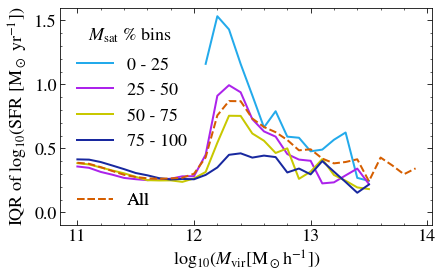

In [152]:
for ip in range(4):
    plt.plot(logMs, new_iqrs_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    
plt.plot(logMs, orig_iqrs, color=palette_tab10[3], linestyle="dashed", label="All")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles=handles[:-1],loc="upper left", bbox_to_anchor=(0,0.85))
ax.add_artist(leg)
leg = ax.legend(handles=handles[-1:], loc="lower left")
ax.add_artist(leg)  

    
#plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.annotate(r"$M_{\rm sat}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.annotate("IQR for each"+ "\n" + r"$M_{\rm sat}$ bin", (0.7,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-0.1,1.6)

#plt.savefig("../figures/iqr_msat.pdf", format="pdf", bbox_inches="tight")

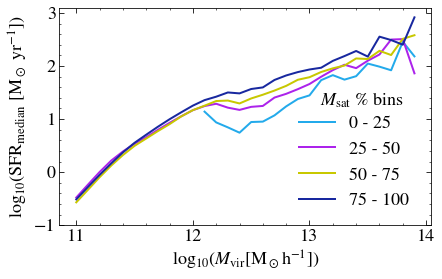

In [151]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    

    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$M_{\rm sat}$ % bins", (0.7,0.55), xycoords="axes fraction", ha="left")
#plt.annotate("Median of each"+ "\n" + r"$M_{\rm sat}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)

#plt.savefig("../figures/median_msat.pdf", format="pdf", bbox_inches="tight")

In [ ]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
logM = 11
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(sum_sat_mass[mask2])
mask_high = sum_sat_mass[mask2] > median
mask_low = sum_sat_mass[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(sum_sat_mass[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (sum_sat_mass[mask2] > percentiles[i]) & (sum_sat_mass[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, cumulative=True,label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"CDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.2), xycoords="axes fraction", ha="right", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by $\rm \widetilde{V}_{max}$", (0.3,0.85), xycoords="axes fraction", ha="right")

#plt.savefig("../figures/cdf_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")